Celda 1: Configuración e Importaciones
Importaremos las herramientas gráficas y las clases que ya construimos con arquitectura limpia.

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..', '..')))

from src.data.load_data import RepositorioVentas
from src.ml.preprocess import ProcesadorDemanda
from src.ml.train import EntrenadorDemanda
from src.ml.evaluate import EvaluadorModelos

Celda 2: Ejecución del Pipeline
Utilizamos nuestras entidades para procesar los datos de tu dataset local. (Asegúrate de cambiar "ruta_a_tu_dataset.csv" por la ruta real donde tengas el archivo descargado de Kaggle).

In [3]:
ruta_dataset = "../../Retail_Sales_Data.csv" 

repositorio = RepositorioVentas(ruta_dataset)
datos_crudos = repositorio.cargar_datos_estructurados()

preprocesador = ProcesadorDemanda(datos_crudos)
datos_procesados = preprocesador.ejecutar_transformacion()

caracteristicas = ['Mes', 'DiaSemana', 'Categoria_Codificada']
objetivo = 'DemandaTotal'

entrenador = EntrenadorDemanda(datos_procesados, caracteristicas, objetivo)
modelos_entrenados, X_prueba, y_prueba = entrenador.generar_modelos_entrenados()

evaluador = EvaluadorModelos(modelos_entrenados, X_prueba, y_prueba)
metricas = evaluador.calcular_metricas()

Celda 3: Visualización de Importancia de Características
Extraemos el peso de cada variable utilizando el modelo de Bosque Aleatorio.

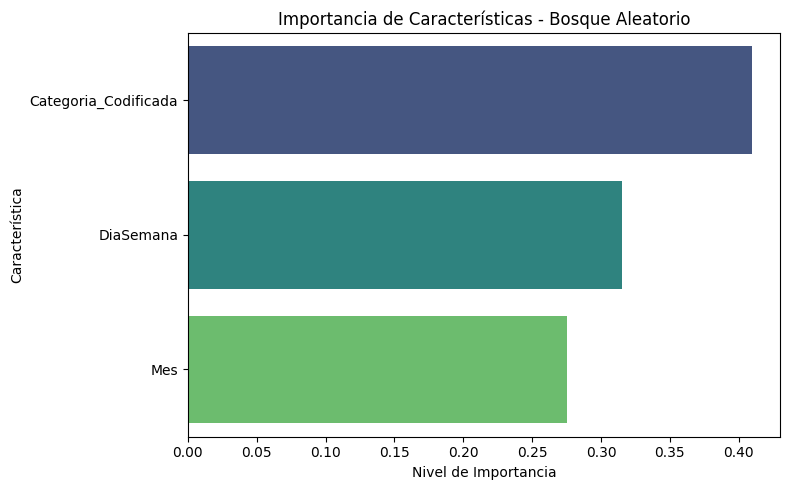

In [4]:
modelo_rf = modelos_entrenados['BosqueAleatorio']
importancias = modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    'Caracteristica': caracteristicas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Caracteristica', data=df_importancias, hue='Caracteristica', palette='viridis', legend=False)
plt.title('Importancia de Características - Bosque Aleatorio')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

Celda 4: Visualización de Valores Reales vs Predichos
Comparamos visualmente ambos modelos para el análisis de errores.

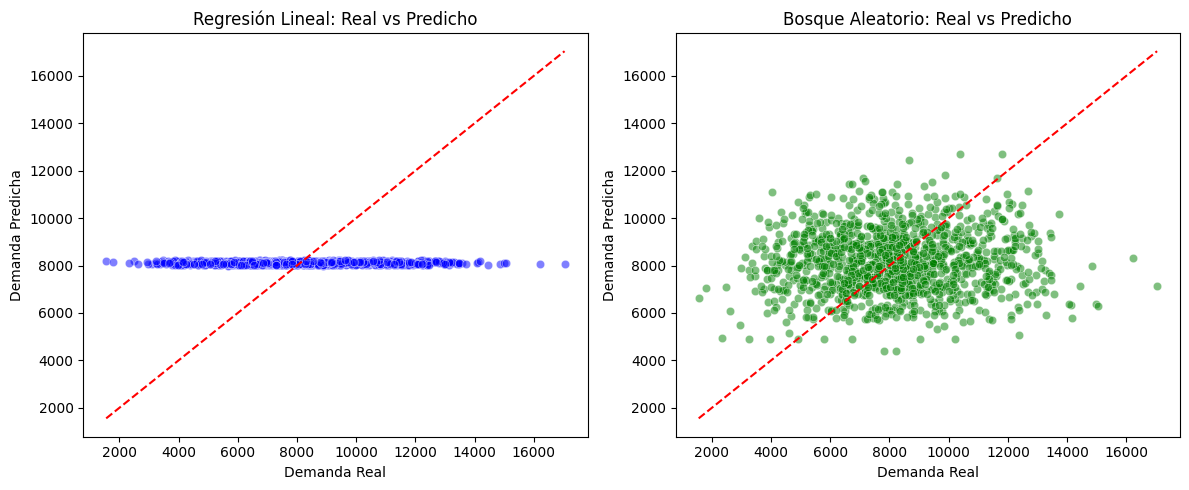

In [5]:
predicciones_lr = modelos_entrenados['RegresionLineal'].predict(X_prueba)
predicciones_rf = modelo_rf.predict(X_prueba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_prueba, y=predicciones_lr, alpha=0.5, color='blue')
plt.plot([y_prueba.min(), y_prueba.max()], [y_prueba.min(), y_prueba.max()], 'r--')
plt.title('Regresión Lineal: Real vs Predicho')
plt.xlabel('Demanda Real')
plt.ylabel('Demanda Predicha')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_prueba, y=predicciones_rf, alpha=0.5, color='green')
plt.plot([y_prueba.min(), y_prueba.max()], [y_prueba.min(), y_prueba.max()], 'r--')
plt.title('Bosque Aleatorio: Real vs Predicho')
plt.xlabel('Demanda Real')
plt.ylabel('Demanda Predicha')

plt.tight_layout()
plt.show()